In [366]:
import math
import numpy as np

In [367]:
class Value:
    def __init__(self, data, children=(), op='', label = ''):
        self.data = data
        self.grad = 0.0 #zero means no effect
        self._prev = set(children)
        self._op = op
        self.label = label
        self._backward = lambda : None
    
    def __repr__(self):
        return f'Value(data={self.data})'
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, children=(self, other), op='+')

        def  bc():
            self.grad += 1.0 * out.grad #+= multivariate case
            other.grad += 1.0 * out.grad

        out._backward = bc  
        return out
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, children=(self, other), op='*')

        def  bc():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = bc  
        return out
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int,float powers for now"
        out = Value(self.data ** other, (self, ), f'**{other}')

        def  bc():
            self.grad += other * (self.data ** (other - 1)) * out.grad

        out._backward = bc  
        return out
        
    def __neg__(self):
        return self * -1
    
    def __sub__(self, other):
        return self + (-other)
    
    def __rsub__(self, other): # other - self
        return other + (-self)

    
    def __radd__(self, other): # other + self
        return self + other
    
    def __rmul__(self, other): #other * self 2 * v
        return self * other
    
    def __truediv__(self, other): #self / other
        return self * (other ** -1)

    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def bc():
            self.grad += out.data * out.grad

        out._backward = bc
        return out

    def tanh(self):
        n = self.data
        t = (math.exp(2 * n) - 1) / (math.exp(2 * n) + 1)
        out = Value(t, (self, ), 'tanh')

        def  bc():
            self.grad += (1 - t ** 2) * out.grad

        out._backward = bc
        return out
    
    def backward(self):
        topo = []
        vis = set()

        def build_topo(u):
            if u not in vis:
                vis.add(u)
                for i in u._prev:
                    build_topo(i)    
                topo.append(u)

        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [368]:
def trace(root):
    nodes, edges = set(), set()

    def build(u):
        if u not in nodes:
            nodes.add(u)

            for i in u._prev:
                edges.add((i, u))
                build(i)

    build(root)

    return nodes, edges


from graphviz import Digraph

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) #left to right

    nodes, edges = trace(root)

    for u in nodes:
        uid = str(id(u))

        #for any value / leaf node create a rectangular
        dot.node(name=uid, label='{%s | data %.4f | grad %.4f}' % (u.label, u.data, u.grad), shape='record')

        if u._op:
            # if this value is a result of some operation, create a op node for it
            dot.node(name=uid + u._op, label= u._op)

            #and connect this node to it
            dot.edge(uid + u._op, uid)

    for u, v in edges:
        #connect u to op node of v
        dot.edge(str(id(u)), str(id(v)) + v._op)

    return dot

In [369]:
class Neuron:
    def __init__(self, n_input):
        self.w = [Value(np.random.uniform(-1, 1)) for i in range(n_input)]
        self.b = Value(np.random.uniform(-1, 1))

    def __call__(self, x):
        #w *x + b n = Neuron(2) , n([1, 2])
        #print(list(zip(self.w, x)))

        #act = sum(wi * xi for wi, xi in zip(self.w, x)) + self.b #or
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)

        out = act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]
    
c = 1 * Value(9.0)
x = [2.0, 3.0]
n = Neuron(2)
n(x)

Value(data=-0.3444137330118095)

In [370]:
class Layer:
    def __init__(self, n_input, n_output):
        self.neurons = [Neuron(n_input) for _ in range(n_output)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        return [p for n in self.neurons for p in n.parameters() ]
    
x = [2.0, 3.0]
n = Layer(2, 3)
n(x)


[Value(data=0.9984703683602036),
 Value(data=0.5497055387025587),
 Value(data=0.5418437723521317)]

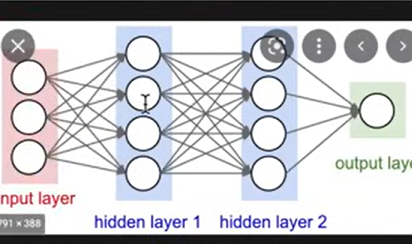


In [371]:
class MLP:
    def __init__(self, nin, nouts):#nouts an array having sizes of output layer[]
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i + 1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers: #calling sequentailly
            x = layer(x)

        return x
    
    def parameters(self):
        return [p for l in self.layers for p in l.parameters() ]

x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
o = n(x)
o.backward()


In [372]:
#draw_dot(o)

In [373]:
xs = [[2.0, 3.0, -1.0],
      [3.0, -1.0, 0.5],
      [0.5, 1.0, 1.0],
      [1.0, 1.0, 1.0]]

ys = [1.0, -1.0, -1.0, 1.0] #desired target

In [387]:
for k in range(100):

    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((ygt - yout) ** 2 for ygt, yout in zip(ys, ypred))

    #backward pass
    for p in n.parameters():
        p.grad = 0.0 #common mistakes
    
    loss.backward()

    #update
    for p in n.parameters():
        p.data += -0.05 * p.grad
    
    if k % 10 == 0: 
        print(k, loss.data)

0 0.011626813236946174
10 0.010653908508174433
20 0.00982153887394997
30 0.009102096199149461
40 0.008474652413300652
50 0.007923073773822394
60 0.007434735480286593
70 0.0069996260018124834
80 0.006609710586958957
90 0.006258470917825056


In [388]:
ypred

[Value(data=0.9968438640604255),
 Value(data=-0.9700243353304246),
 Value(data=-0.9539485150548654),
 Value(data=0.9457621136257133)]

In [376]:
#ygt y ground truth
loss = sum((ygt - yout) ** 2 for ygt, yout in zip(ys, ypred))
loss

Value(data=0.0650775089408261)

In [377]:
ypred = [n(x) for x in xs]
loss = sum((ygt - yout) ** 2 for ygt, yout in zip(ys, ypred))
loss

Value(data=0.06274276278569446)

In [378]:
loss.backward()

In [379]:
n.layers[0].neurons[0].w[0].grad

-0.04578613840916172

In [380]:
n.layers[0].neurons[0].w[0].data
#gradient points toward increase in loss, we want to decrease it, 

0.3618792548393171

In [381]:
len(n.parameters())

41

In [382]:
for p in n.parameters():
    p.data += -0.01 * p.grad

In [383]:
n.layers[0].neurons[0].w[0].data


0.3623371162234087